<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/Practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [80]:
# Parameters
C = 4  # nF
gL = 0.05  # nS
EL = -65  # mV

Vth = -40  # mV
Vr = -70  # mV
tref = 5  # ms

In [64]:
T = 2000  # ms
dt = 0.1  # ms
steps = int(T/dt)

t_vec = np.linspace(0, T, steps+1)

In [69]:
Ie = np.zeros((len(t_vec), ))

t1 = 100  # ms
t2 = t1 + 1000  # ms

n1 = int(t1/dt)
n2 = int(t2/dt)

Ie[n1:n2+1] = 1.5  # mA

In [86]:
V = np.zeros((len(t_vec), ))
V[0] = EL
tspike = [-1]
flag = True

for n in range(steps):
  deriv = (-gL*(V[n]-EL) + Ie[n])/C
  V[n+1] = V[n] + dt*deriv

  if V[n+1] > Vth and flag:
    tspike.append(n*dt)
    V[n+1] = Vr
    flag = False

  if int(n/dt) > tref + tspike[-1]:
    flag = True


In [90]:
print(tspike)

[-1, 243.20000000000002, 398.8, 554.4, 710.0, 865.6, 1021.2]


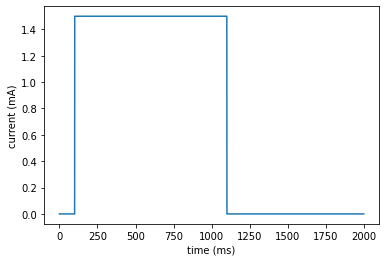

In [87]:
plt.figure()
plt.plot(t_vec, Ie)
plt.xlabel('time (ms)')
plt.ylabel('current (mA)')
plt.show()

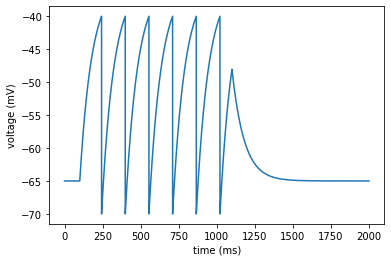

In [88]:
plt.figure()
plt.plot(t_vec, V)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.show()

2432
3988
5543
7100
8656
10212


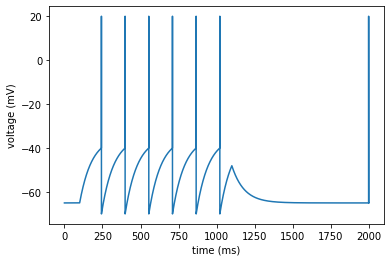

In [92]:
for t in tspike[1:]:
  n = int(t/dt)
  V[n] = + 20

plt.figure()
plt.plot(t_vec, V)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.show()

In [93]:
V = np.zeros((len(t_vec), ))
V[0] = EL
tspike = [-1]
flag = True

for n in range(steps):
  deriv = (-gL*(V[n]-EL)*(Vth-V[n])/(Vth-EL) + Ie[n])/C
  V[n+1] = V[n] + dt*deriv

  if V[n+1] > Vth and flag:
    tspike.append(n*dt)
    V[n+1] = Vr
    flag = False

  if int(n/dt) > tref + tspike[-1]:
    flag = True

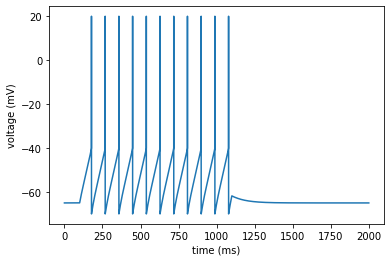

In [94]:
for t in tspike[1:]:
  n = int(t/dt)
  V[n] = + 20

plt.figure()
plt.plot(t_vec, V)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.show()